# Fig 5 — patient-specific ADC target screening (Visium HD)

Reproduces **Fig5** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

> Excluded (non-code): Fig 5a schematic, Fig 5c H&E overlay, Fig 5d summary graphic.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 18`

In [ ]:
# ── Shortcut: load saved h5ad with SPATNIC + cluster annotations ──
adata = sc.read_h5ad(BASE_DIR / 'visiumhd_integrated_epi_spatnic.h5ad')

sample_list = sorted(
    adata.obs['Sample'].unique(),
    key=lambda x: (int(x.split('-')[1].split('_')[0]), x)
)

# ── Override THRESHOLD (SPATNIC scores are already in h5ad, just re-cut) ──
THRESHOLD = 0.5

# Recompute strict_group with new threshold (is_epithelial = cluster denoising, unchanged)
epi_mask = adata.obs['is_epithelial']
adata.obs['strict_group'] = 'Non-epithelial'
adata.obs.loc[epi_mask, 'strict_group'] = 'Epi-Ambiguous'
adata.obs.loc[epi_mask & (adata.obs['spatnic_score_Tumor'] >= THRESHOLD), 'strict_group'] = 'Epi-Tumor'
adata.obs.loc[epi_mask & (adata.obs['spatnic_score_Normal'] >= THRESHOLD), 'strict_group'] = 'Epi-Normal'

print(adata)
print(f'Samples: {len(sample_list)}')
print(f'THRESHOLD: {THRESHOLD}')
print(f'\nstrict_group distribution:')
print(adata.obs['strict_group'].value_counts())

# ── Sample info ──
sample_info = {
    'Pt-1_Pre':       ('SpaceRanger_241126_Pt1_6-8', 'D_Pt_1_Pre'),
    'Pt-1_Resection': ('SpaceRanger_241126_Pt1_6-8', 'A_Pt_1_Re'),
    'Pt-2_Pre':       ('SpaceRanger_240930_Pt2-5',   'A_Pt_2_Pre'),
    'Pt-2_Resection': ('SpaceRanger_240930_Pt2-5',   'D_Pt_2_Resection'),
    'Pt-3_Pre':       ('SpaceRanger_240930_Pt2-5',   'D_Pt_3_Pre_Pt_3_Just_After'),
    'Pt-3_JustAfter': ('SpaceRanger_240930_Pt2-5',   'D_Pt_3_Pre_Pt_3_Just_After'),
    'Pt-3_Resection': ('SpaceRanger_240930_Pt2-5',   'A_Pt_3_Resection'),
    'Pt-4_Pre':       ('SpaceRanger_240930_Pt2-5',   'D_Pt_4_Pre'),
    'Pt-4_Resection': ('SpaceRanger_240930_Pt2-5',   'A_Pt_4_Resection'),
    'Pt-5_Pre':       ('SpaceRanger_240930_Pt2-5',   'D_Pt_5_Pre_Pt_5_Just_After'),
    'Pt-5_JustAfter': ('SpaceRanger_240930_Pt2-5',   'D_Pt_5_Pre_Pt_5_Just_After'),
    'Pt-5_Resection': ('SpaceRanger_240930_Pt2-5',   'A_Pt_5_Resection'),
    'Pt-6_Pre':       ('SpaceRanger_241126_Pt1_6-8', 'D_Pt_6_Pre'),
    'Pt-6_Resection': ('SpaceRanger_241126_Pt1_6-8', 'A_Pt_6_Re'),
    'Pt-7_Pre':       ('SpaceRanger_241126_Pt1_6-8', 'D_Pt_7_Pre'),
    'Pt-7_Resection': ('SpaceRanger_241126_Pt1_6-8', 'A_Pt_7_Resection'),
    'Pt-8_Pre':       ('SpaceRanger_241126_Pt1_6-8', 'D_Pt_8_Pre'),
    'Pt-8_Resection': ('SpaceRanger_241126_Pt1_6-8', 'A_Pt_8_Resection'),
    'Pt-9_Pre':        ('SpaceRanger_241210_Pt9-12', 'A_Pt_9_Pre'),
    'Pt-9_Resection':  ('SpaceRanger_241210_Pt9-12', 'D_Pt_9_Resection'),
    'Pt-10_Pre':       ('SpaceRanger_241210_Pt9-12', 'A_Pt_10_Pre'),
    'Pt-10_Resection': ('SpaceRanger_241210_Pt9-12', 'D_Pt_10_Resection'),
    'Pt-11_Pre':       ('SpaceRanger_241210_Pt9-12', 'A_Pt_11_Pre_P11_just_after'),
    'Pt-11_JustAfter': ('SpaceRanger_241210_Pt9-12', 'A_Pt_11_Pre_P11_just_after'),
    'Pt-11_Resection': ('SpaceRanger_241210_Pt9-12', 'D_Pt_11_Resection'),
    'Pt-12_Pre':       ('SpaceRanger_241210_Pt9-12', 'A_Pt_12_Pre'),
    'Pt-12_Resection': ('SpaceRanger_241210_Pt9-12', 'D_Pt_12_Resection'),
    'Pt-13_Pre':       ('SpaceRanger_Pt13-16',       'A_Pt_13_Pre_P13_just_after'),
    'Pt-13_JustAfter': ('SpaceRanger_Pt13-16',       'A_Pt_13_Pre_P13_just_after'),
    'Pt-13_Resection': ('SpaceRanger_Pt13-16',       'D_Pt_13_Resection'),
    'Pt-14_Pre':       ('SpaceRanger_Pt13-16',       'A_Pt_14_Pre'),
    'Pt-14_Resection': ('SpaceRanger_Pt13-16',       'D_Pt_14_Resection'),
    'Pt-15_Pre':       ('SpaceRanger_Pt13-16',       'A_Pt_15_Pre'),
    'Pt-15_Resection': ('SpaceRanger_Pt13-16',       'D_Pt_15_Resection'),
    'Pt-16_Pre':       ('SpaceRanger_Pt13-16',       'A_Pt_16_Pre'),
    'Pt-16_Resection': ('SpaceRanger_Pt13-16',       'D_Pt_16_Resection'),
    'Pt-17_Pre':       ('SpaceRanger_Pt17-20',  'A_Pt_17_Pre'),
    'Pt-17_Resection': ('SpaceRanger_Pt17-20',  'D_Pt_17_Re'),
    'Pt-18_Pre':       ('SpaceRanger_Pt17-20',  'A_Pt_18_Pre'),
    'Pt-18_Resection': ('SpaceRanger_Pt17-20',  'D_Pt_18_Resection'),
    'Pt-19_Pre':       ('SpaceRanger_Pt17-20',  'A_Pt_19_Pre'),
    'Pt-19_Resection': ('SpaceRanger_Pt17-20',  'D_Pt_19_Resection'),
    'Pt-20_Pre':       ('SpaceRanger_Pt17-20',  'A_Pt_20_Pre'),
    'Pt-20_Resection': ('SpaceRanger_Pt17-20',  'D_Pt_20_Resection'),
    'Pt-21_Pre':       ('SpaceRanger_Pt21-24',  'A_Pt_21_Pre'),
    'Pt-21_Resection': ('SpaceRanger_Pt21-24',  'D_Pt_21_Resection'),
    'Pt-22_Pre':       ('SpaceRanger_Pt21-24',  'A_Pt_22_Pre'),
    'Pt-22_Resection': ('SpaceRanger_Pt21-24',  'D_Pt_22_Resection'),
    'Pt-23_Pre':       ('SpaceRanger_Pt21-24',  'A_Pt_23_Pre'),
    'Pt-23_Resection': ('SpaceRanger_Pt21-24',  'D_Pt_23_Resection'),
    'Pt-24_Pre':       ('SpaceRanger_Pt21-24',  'A_Pt_24_Pre'),
    'Pt-24_Resection': ('SpaceRanger_Pt21-24',  'D_Pt_24_Resection'),
}

def get_sr_base(sample_name):
    batch, source_dir = sample_info[sample_name]
    return BASE_DIR / batch / 'SpaceRanger_Output' / source_dir

def get_he_image_path(sample_name):
    return get_sr_base(sample_name) / 'spatial' / 'tissue_hires_image.png'

def get_scalefactors(sample_name):
    sf_path = get_sr_base(sample_name) / 'binned_outputs' / 'square_016um' / 'spatial' / 'scalefactors_json.json'
    with open(sf_path) as f:
        return _json.load(f)

### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 20`

In [ ]:
adc_targets = {
    # FDA Approved (solid tumor)
    'ERBB2':    ('HER2 — T-DXd / T-DM1',              'Approved'),
    'TACSTD2':  ('TROP-2 — Sacituzumab / Dato-DXd',   'Approved'),
    'NECTIN4':  ('Nectin-4 — Enfortumab vedotin',     'Approved'),
    'FOLR1':    ('FRα — Mirvetuximab soravtansine',   'Approved'),
    'F3':       ('Tissue Factor — Tisotumab vedotin', 'Approved'),
    'MET':      ('c-MET — Telisotuzumab vedotin',     'Approved'),
    # Phase III
    'ERBB3':    ('HER3 — Patritumab deruxtecan',      'Phase III'),
    'EGFR':     ('EGFR — Multiple ADCs',              'Phase III'),
    'CEACAM5':  ('CEACAM5 — Tusamitamab ravtansine',  'Phase III'),
    'ROR1':     ('ROR1 — Zilovertamab vedotin',       'Phase III'),
    'EPCAM':    ('EpCAM — CX-2051 / Multiple ADCs',   'Phase III'),
    'CDH6':     ('Cadherin-6 — DS-6000',              'Phase III'),
    'ITGB6':    ('Integrin β6 — SGN-B6A',             'Phase III'),
    'CLDN18':   ('Claudin 18.2 — CMG901 / AZD0901',   'Phase III'),
    'DLL3':     ('DLL3 — Rova-T / I-DXd',             'Phase III'),
    'CD276':    ('B7-H3 — Ifinatamab deruxtecan',     'Phase III'),  # updated: I-DXd now Phase III
    # Phase I/II
    'CLDN6':    ('Claudin-6 — Multiple ADCs',         'Phase I/II'),
    'CLDN4':    ('Claudin-4 — Multiple ADCs',         'Phase I/II'),
    'CLDN1':    ('Claudin-1 — ALE.P02',               'Phase I/II'),
    'EPHA2':    ('EPHA2 — Multiple ADCs',             'Phase I/II'),
    'EPHB4':    ('EPHB4 — Multiple ADCs',             'Phase I/II'),
    'AXL':      ('AXL — Enapotamab vedotin',          'Phase I/II'),
    'FGFR2':    ('FGFR2 — Aprutumab ixadotin',        'Phase I/II'),
    'FGFR3':    ('FGFR3 — Multiple ADCs',             'Phase I/II'),
    'L1CAM':    ('L1CAM — Multiple ADCs',             'Phase I/II'),
    'ICAM1':    ('ICAM1 — Multiple ADCs',             'Phase I/II'),
    'ALCAM':    ('CD166 / ALCAM — CX-2009',           'Phase I/II'),
    'PTK7':     ('PTK7 — Cofetuzumab',                'Phase I/II'),
    'ROR2':     ('ROR2 — BA3021',                     'Phase I/II'),
    'MSLN':     ('Mesothelin — Anetumab ravtansine',  'Phase I/II'),
    'MUC16':    ('MUC16 — DMUC4064A',                 'Phase I/II'),
    'MUC1':     ('MUC1 — DS-3939 / Multiple ADCs',    'Phase I/II'),
    'MUC13':    ('MUC13 — Multiple ADCs',             'Phase I/II'),
    'MUC17':    ('MUC17 — Multiple ADCs',             'Phase I/II'),
    'GUCY2C':   ('GUCY2C — TAK-164 / TAK-264',        'Phase I/II'),
    'SLC34A2':  ('NaPi2b — Upifitamab rilsodotin',    'Phase I/II'),
    'SLC39A6':  ('LIV-1 — Ladiratuzumab vedotin',     'Phase I/II'),
    'VTCN1':    ('B7-H4 — AZD8205 / SGN-B7H4V',       'Phase I/II'),
    'GPNMB':    ('GPNMB — Glembatumumab vedotin',     'Phase I/II'),
    'TPBG':     ('5T4 / TPBG — Multiple ADCs',        'Phase I/II'),
    'CDH3':     ('P-cadherin — PCA062',               'Phase I/II'),
    'LRRC15':   ('LRRC15 — ABBV-085',                 'Phase I/II'),
    'FAP':      ('FAP — Multiple ADCs',               'Phase I/II'),
    'PDPN':     ('Podoplanin — Multiple ADCs',        'Phase I/II'),
    'CD248':    ('Endosialin / CD248 — Multiple ADCs','Phase I/II'),
    'CD46':     ('CD46 — FOR46',                      'Phase I/II'),
    'TFRC':     ('CD71 / Transferrin receptor',       'Phase I/II'),
    'CD44':     ('CD44v6 — Bivatuzumab mertansine',   'Phase I/II'),
    # === Added 2026-06: clinical-stage solid-tumor ADC targets verified by audit (NCT/PMID/DOI on file) ===
    'CDH17':    ('Cadherin-17 — AMT-676 / 7MW4911',   'Phase I/II'),
    'RNF43':    ('RNF43 — SC-006',                    'Phase I/II'),
    'CEACAM6':  ('CEACAM6 — EBC-129',                 'Phase I/II'),
    'FOLH1':    ('PSMA — anti-PSMA ADCs',             'Phase I/II'),
    'STEAP1':   ('STEAP1 — DSTP3086S / ABBV-969',     'Phase I/II'),
    'STEAP2':   ('STEAP2 — AZD0516',                  'Phase I/II'),
    'GPC3':     ('Glypican-3 — ZW251 / BC2027',       'Phase I/II'),
    'ENPP3':    ('ENPP3 — AGS-16C3F',                 'Phase I/II'),
    'HAVCR1':   ('TIM-1 — CDX-014',                   'Phase I/II'),
    'SLC44A4':  ('SLC44A4 / AGS-5 — ASG-5ME',         'Phase I/II'),
    'MELTF':    ('CD228 / melanotransferrin — SGN-CD228A', 'Phase I/II'),
    'SEZ6':     ('SEZ6 — ABBV-011 / ABBV-706',        'Phase I/II'),
    'SLITRK6':  ('SLITRK6 — Sirtratumab vedotin',     'Phase I/II'),
    'CA6':      ('CA6 — SAR566658',                   'Phase I/II'),
    'CD70':     ('CD70 — SGN-CD70A',                  'Phase I/II'),
    'CEACAM5':  ('CEACAM5 — Tusamitamab ravtansine',  'Phase III'),  # (kept; tusamitamab Ph III)
    'FN1':      ('EDB-fibronectin — PYX-201',         'Phase I/II'),
    'KAAG1':    ('KAAG1 — ADCT-901',                  'Phase I/II'),
    'NOTCH3':   ('Notch-3 — PF-06650808',             'Phase I/II'),
    'DLK1':     ('DLK1 — ADCT-701',                   'Phase I/II'),
    'GPR20':    ('GPR20 — DS-6157a',                  'Phase I/II'),
    'TM4SF1':   ('TM4SF1 / L6 — AGX101',              'Phase I/II'),
    'LY75':     ('CD205 / DEC-205 — MEN1309',         'Phase I/II'),
    'LAMP1':    ('LAMP1 — SAR428926',                 'Phase I/II'),
    'LY6E':     ('LY6E — DLYE5953A',                  'Phase I/II'),
    # NOTE: hematologic-only approved ADC targets (CD33/CD30/CD22/CD79B/BCMA/CD19/CD74) are intentionally
    # excluded — this list is solid-tumor scoped and those antigens are not epithelial-tumor expressed.
}

# === Undeveloped cell-surface candidates (no clinical/approved ADC), 3 groups ===
# Screen = make_undev_3way.py -> undeveloped_3way_ranking.csv:
#   filters: SURFY antibody-accessible (<=6 TM & largest extracellular segment >=80 aa); undeveloped;
#            EPITHELIAL-enriched (epi/non-epi mean expr >=2 -> removes TME/immune/stromal contaminants).
#   samples: QUALITY = mean Epi-Tumor reads/bin >=1000 (per-tumor-bin reads; NOT stroma-confounded; excludes
#            Pt-1/2/3) + JustAfter excluded -> 18 (Pre 9 / Res 9).
#   metrics (within-sample percentile, depth-robust):
#     OVERALL = consistently tumor-SPECIFIC in both Pre&Res (min of group means of Tumor-Normal pct);
#     Pre = LONGITUDINAL tumor-EXPRESSION higher in Pre (within-sample pct of mean Epi-Tumor expr, Pre>Res).
#     Resection = significant tumor-high in the MOST Resection cases (make_resection_sig.py ->
#       resection_significance.csv; per-sample Tumor-vs-Normal AUROC+FDR). NB: signal is weak in Resection
#       (only DPEP1 reaches 3/9 cases; rest 1/9, AUROC~0.55) -> DPEP1-centered. Top 5 each.
NOVEL_STATUS = 'Undeveloped (surface)'
novel_surface = {
    # overall
    'CD47':    'CD47 — undev (overall)',
    'FAT1':    'FAT1 — undev (overall)',
    'SLC3A2':  'CD98hc / SLC3A2 — undev (overall)',
    'LRP11':   'LRP11 — undev (overall)',
    'GABRE':   'GABRE — undev (overall)',
    # Pre
    'DSG3':    'DSG3 — undev (Pre)',
    'GRIN2D':  'GRIN2D — undev (Pre)',
    'CDH16':   'CDH16 — undev (Pre)',
    'LY6D':    'LY6D — undev (Pre)',
    'UPK3B':   'UPK3B — undev (Pre)',
    # Resection (significant tumor-high in the most Resection cases; DPEP1-centered)
    'DPEP1':   'DPEP1 — undev (Resection)',
    'APCDD1':  'APCDD1 — undev (Resection)',
    'EREG':    'EREG — undev (Resection)',
    'AREG':    'AREG — undev (Resection)',
    'PTPRO':   'PTPRO — undev (Resection)',
}
for _g, _lab in novel_surface.items():
    adc_targets[_g] = (_lab, NOVEL_STATUS)

gene_list = [g for g in adc_targets if g in adata.var_names]
missing = [g for g in adc_targets if g not in adata.var_names]
print(f'Target genes: {len(gene_list)}/{len(adc_targets)} found '
      f'({len(adc_targets)-len(novel_surface)} ADC + {len(novel_surface)} novel surface)')
if missing:
    print(f'Missing from panel: {missing}')

status_colors = {
    'Approved':            '#1B5E20',
    'Phase III':           '#43A047',
    'Phase I/II':          '#A5D6A7',
    'Undeveloped (surface)': '#7E57C2',   # purple — undeveloped novel candidates
}
status_order_full = ['Approved', 'Phase III', 'Phase I/II', 'Undeveloped (surface)']
for _s in status_order_full:
    print(f"{_s}: {sum(1 for g in gene_list if adc_targets[g][1]==_s)}")

### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 22`

In [ ]:
diff_records = []
frac_records = []
count_records = []

for i, sample_name in enumerate(sample_list):
    print(f'[{i+1}/{len(sample_list)}] {sample_name}...', end=' ', flush=True)

    mask = adata.obs['Sample'] == sample_name
    adata_sub = adata[mask].copy()

    tumor_mask = adata_sub.obs['strict_group'] == 'Epi-Tumor'
    normal_mask = adata_sub.obs['strict_group'] == 'Epi-Normal'

    n_tumor = tumor_mask.sum()
    n_normal = normal_mask.sum()
    n_epi_amb = (adata_sub.obs['strict_group'] == 'Epi-Ambiguous').sum()
    n_non_epi = (adata_sub.obs['strict_group'] == 'Non-epithelial').sum()
    count_records.append({
        'Sample': sample_name,
        'n_tumor': int(n_tumor), 'n_normal': int(n_normal),
        'n_epi_ambiguous': int(n_epi_amb), 'n_non_epi': int(n_non_epi),
    })

    if n_tumor < 10 or n_normal < 10:
        diff_records.append({'Sample': sample_name, **{g: np.nan for g in gene_list}})
        frac_records.append({'Sample': sample_name, **{g: np.nan for g in gene_list}})
        print(f'SKIP (EpiTumor={n_tumor}, EpiNormal={n_normal})')
    else:
        # Fraction expressing (raw counts > 0)
        X_raw = adata_sub[:, gene_list].X
        if sp.issparse(X_raw):
            frac_tumor = np.asarray((X_raw[tumor_mask.values] > 0).mean(axis=0)).ravel()
            frac_normal = np.asarray((X_raw[normal_mask.values] > 0).mean(axis=0)).ravel()
        else:
            frac_tumor = (X_raw[tumor_mask.values] > 0).mean(axis=0)
            frac_normal = (X_raw[normal_mask.values] > 0).mean(axis=0)
        frac_records.append({'Sample': sample_name, **{g: d for g, d in zip(gene_list, frac_tumor - frac_normal)}})

        # Mean expression difference (normalized)
        sc.pp.normalize_total(adata_sub)
        sc.pp.log1p(adata_sub)
        X = adata_sub[:, gene_list].X
        if sp.issparse(X):
            mean_tumor = np.asarray(X[tumor_mask.values].mean(axis=0)).ravel()
            mean_normal = np.asarray(X[normal_mask.values].mean(axis=0)).ravel()
        else:
            mean_tumor = X[tumor_mask.values].mean(axis=0)
            mean_normal = X[normal_mask.values].mean(axis=0)
        diff_records.append({'Sample': sample_name, **{g: d for g, d in zip(gene_list, mean_tumor - mean_normal)}})
        print(f'OK (EpiTumor={n_tumor:,}, EpiNormal={n_normal:,})')

    del adata_sub
    gc.collect()

diff_df = pd.DataFrame(diff_records).set_index('Sample')
frac_df = pd.DataFrame(frac_records).set_index('Sample')
count_df = pd.DataFrame(count_records).set_index('Sample')

meta = adata.obs.drop_duplicates('Sample')[['Sample', 'Patient', 'Timepoint', 'Response']].set_index('Sample')
diff_df = diff_df.join(meta)
diff_df['pt_num'] = diff_df['Patient'].str.extract(r'(\d+)').astype(int)
frac_df = frac_df.join(meta)
frac_df['pt_num'] = frac_df['Patient'].str.extract(r'(\d+)').astype(int)

print(f'\nDiff matrix: {diff_df.shape}')
skipped = count_df[(count_df['n_tumor'] < 10) | (count_df['n_normal'] < 10)]
if len(skipped) > 0:
    print(f'Skipped samples ({len(skipped)}):')
    print(skipped)

### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 24`

In [ ]:
def plot_adc_dotplot(diff_df, frac_df, count_df, gene_list, cbar_label, out_stem, sig_csv, compare_note="", exclude_timepoints=(), show_response=True, show_quality=True, column_order="response", min_depth=0, show_counts=True, max_size=240, font_scale=1.0):
    """ADC-target dot plot (color=Δfraction, size=expr; thick border=significant;
    Response/Timepoint/Mean-reads-per-bin annotation). Used for both §7/§9 and the §12 main figs."""
    # =========================
    # Global style
    # =========================
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.size"] = 14 * font_scale
    mpl.rcParams["axes.titlesize"] = 18 * font_scale
    mpl.rcParams["axes.labelsize"] = 15 * font_scale
    mpl.rcParams["xtick.labelsize"] = 11 * font_scale
    mpl.rcParams["ytick.labelsize"] = 13 * font_scale
    mpl.rcParams["legend.fontsize"] = 11 * font_scale
    mpl.rcParams["legend.title_fontsize"] = 12 * font_scale
    mpl.rcParams["axes.linewidth"] = 1.2
    mpl.rcParams["xtick.major.width"] = 1.2
    mpl.rcParams["ytick.major.width"] = 1.2
    mpl.rcParams["xtick.major.size"] = 4
    mpl.rcParams["ytick.major.size"] = 4

    # =========================
    # 1) Exclude pCR_Resection
    # =========================
    _med_depth = adata.obs[adata.obs["strict_group"] == "Epi-Tumor"].groupby("Sample")["total_counts"].mean()  # mean Epi-Tumor reads/bin
    exc_mask = (((diff_df["Response"] == "pCR") & (diff_df["Timepoint"] == "Resection"))
                | diff_df["Timepoint"].isin(exclude_timepoints)
                | (diff_df.index.to_series().map(_med_depth).fillna(0) < min_depth))
    plot_diff = diff_df.loc[~exc_mask].copy()
    plot_frac = frac_df.loc[~exc_mask].copy()
    plot_count = count_df.loc[plot_diff.index.intersection(count_df.index)].copy()

    # =========================
    # 2) FORCE ORDER
    # =========================
    response_order = ["NR", "MPR", "pCR"]
    timepoint_order = ["Pre", "JustAfter", "Resection"]
    status_order = ["Approved", "Phase III", "Phase I/II", "Undeveloped (surface)"]

    plot_diff["Response"] = pd.Categorical(plot_diff["Response"], categories=response_order, ordered=True)
    plot_diff["Timepoint"] = pd.Categorical(plot_diff["Timepoint"], categories=timepoint_order, ordered=True)
    plot_frac["Response"] = pd.Categorical(plot_frac["Response"], categories=response_order, ordered=True)
    plot_frac["Timepoint"] = pd.Categorical(plot_frac["Timepoint"], categories=timepoint_order, ordered=True)

    resp_map = {k: i for i, k in enumerate(response_order)}
    tp_map = {k: i for i, k in enumerate(timepoint_order)}

    plot_diff["resp_order"] = plot_diff["Response"].map(resp_map).astype(int)
    plot_diff["tp_order"] = plot_diff["Timepoint"].map(tp_map).astype(int)

    if "pt_num" not in plot_diff.columns:
        plot_diff["pt_num"] = plot_diff["Patient"].astype(str).str.extract(r"(\d+)")[0].fillna(9999).astype(int)

    _sortcols = ["tp_order", "resp_order", "pt_num", "Patient"] if column_order == "timepoint" else ["resp_order", "tp_order", "pt_num", "Patient"]
    plot_diff = plot_diff.sort_values(_sortcols, ascending=[True, True, True, True]).copy()

    plot_frac = plot_frac.loc[plot_diff.index].copy()
    plot_count = plot_count.loc[plot_diff.index].copy()

    # =========================
    # 3) Row order
    # =========================
    status_rank = {k: i for i, k in enumerate(status_order)}
    gene_list_sorted = sorted(
        gene_list,
        key=lambda g: (status_rank[adc_targets[g][1]], adc_targets[g][0])
    )

    # =========================
    # 4) Prepare matrices
    # =========================
    expr_mat = plot_diff[gene_list_sorted].values.T
    frac_mat = plot_frac[gene_list_sorted].values.T

    sample_names = plot_diff.index.tolist()
    gene_labels = [adc_targets[g][0] for g in gene_list_sorted]

    n_genes = len(gene_list_sorted)
    n_samples = len(sample_names)

    # x-axis labels
    def _fmt_count(n):
        if n >= 1000:
            return f"{n/1000:.1f}k"
        return str(n)

    xlabels = []
    for s in sample_names:
        pt = plot_diff.loc[s, "Patient"]
        tp = plot_diff.loc[s, "Timepoint"]
        nt = int(plot_count.loc[s, "n_tumor"])
        nn = int(plot_count.loc[s, "n_normal"]) if "n_normal" in plot_count.columns else None
        if show_counts:
            xlabels.append(f"{pt}_{tp} (T={_fmt_count(nt)}" + (f", N={_fmt_count(nn)})" if nn is not None else ")"))
        else:
            xlabels.append(f"{pt}_{tp}")

    # =========================
    # 5) Dot size scaling
    # =========================
    sizes = np.abs(expr_mat.ravel())
    valid_sizes = sizes[~np.isnan(sizes)]

    min_size = 12
    # max_size now a parameter (default 240)

    if len(valid_sizes) > 0 and valid_sizes.max() > 0:
        sizes_scaled = np.where(
            np.isnan(sizes), 0,
            min_size + (sizes / valid_sizes.max()) * (max_size - min_size)
        )
    else:
        sizes_scaled = np.zeros_like(sizes)

    # =========================
    # 6) Color normalization
    # =========================
    abs_max = np.nanmax(np.abs(frac_mat))
    if not np.isfinite(abs_max) or abs_max == 0:
        abs_max = 1.0
    vlim = max(1.0, np.ceil(abs_max * 10) / 10)
    norm = plt.Normalize(vmin=-vlim, vmax=vlim)

    # =========================
    # 7) Colors
    # =========================
    response_colors_map = {"NR": "#C0392B", "MPR": "#E69F00", "pCR": "#4C78A8"}
    timepoint_colors_map = {"Pre": "#D9D9D9", "JustAfter": "#969696", "Resection": "#252525"}

    # =========================
    # 8) Figure
    # =========================
    fig, ax = plt.subplots(figsize=(max(20, n_samples * 0.42), max(9, n_genes * 0.32)))

    xx, yy = np.meshgrid(np.arange(n_samples), np.arange(n_genes))
    xx = xx.ravel()
    yy = yy.ravel()
    colors = frac_mat.ravel()

    # significant dots get a thick black border (FDR<0.05 AND AUROC>=0.7, Tumor>Normal)
    _sig_df = pd.read_csv(BASE_DIR / sig_csv, index_col=0)
    _sigm = _sig_df.reindex(index=gene_list_sorted, columns=sample_names).values.ravel()
    _sig = np.nan_to_num(_sigm.astype(float)) > 0.5
    _lw = np.where(_sig, 1.8, 0.35)
    _ec = np.where(_sig, "black", "#2B2B2B")
    sc_plot = ax.scatter(
        xx, yy, c=colors, s=sizes_scaled,
        cmap="RdBu_r", norm=norm,
        edgecolors=_ec, linewidths=_lw, zorder=3,
    )
    #fig.text(0.01, 0.99, "thick black border = significant (FDR<0.05 & AUROC\u22650.7, Tumor>Normal)  |  "
    #         f"n={int(_sig.sum())} dots", fontsize=10, fontweight="bold", ha="left", va="top")

    # =========================
    # 9) Axes formatting
    # =========================
    ax.set_xticks(range(n_samples))
    ax.set_xticklabels(xlabels, rotation=90, ha="center", va="top", fontsize=9*font_scale)
    ax.set_yticks(range(n_genes))
    ax.set_yticklabels(gene_labels, fontsize=14*font_scale)

    ax.set_xlim(-0.9, n_samples - 0.1)
    _yslots = [-1.35, -2.15, -2.95]
    _bars_gu = (["quality"] if show_quality else []) + ["timepoint"] + (["response"] if show_response else [])
    _ypos = {b: _yslots[i] for i, b in enumerate(_bars_gu)}
    ax.set_ylim(_yslots[len(_bars_gu) - 1] - 0.55, n_genes - 0.3)
    ax.invert_yaxis()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="both", color="#ECECEC", linewidth=0.7)

    # =========================
    # 10) Horizontal separators for status groups
    # =========================
    n_approved = sum(adc_targets[g][1] == "Approved" for g in gene_list_sorted)
    n_phase3 = sum(adc_targets[g][1] == "Phase III" for g in gene_list_sorted)
    n_phase12 = sum(adc_targets[g][1] == "Phase I/II" for g in gene_list_sorted)

    if n_approved > 0:
        ax.axhline(y=n_approved - 0.5, color="#4A4A4A", linewidth=1.5)
    if n_phase3 > 0:
        ax.axhline(y=n_approved + n_phase3 - 0.5, color="#4A4A4A", linewidth=1.5)
    if n_phase12 > 0:
        ax.axhline(y=n_approved + n_phase3 + n_phase12 - 0.5, color="#4A4A4A", linewidth=1.5)

    # =========================
    # 11) Vertical separators
    # =========================
    current = 0
    response_boundaries = []
    for resp in response_order:
        count = (plot_diff["Response"].astype(str) == resp).sum()
        current += count
        if current < n_samples:
            response_boundaries.append(current - 0.5)

    if show_response:
        for xb in response_boundaries:
            ax.axvline(x=xb, color="black", linewidth=1.6, linestyle="-")

    # Timepoint boundaries
    if column_order == "response":
        start_idx = 0
        for resp in response_order:
            sub = plot_diff[plot_diff["Response"].astype(str) == resp]
            if len(sub) == 0:
                continue
            c_pre = (sub["Timepoint"].astype(str) == "Pre").sum()
            c_ja = (sub["Timepoint"].astype(str) == "JustAfter").sum()
            c_res = (sub["Timepoint"].astype(str) == "Resection").sum()
            if c_pre > 0 and (c_ja + c_res) > 0:
                ax.axvline(x=start_idx + c_pre - 0.5, color="#7F7F7F", linewidth=1.0, linestyle="--", alpha=0.95)
            if (c_pre + c_ja) > 0 and c_res > 0 and c_ja > 0:
                ax.axvline(x=start_idx + c_pre + c_ja - 0.5, color="#7F7F7F", linewidth=1.0, linestyle="--", alpha=0.95)
            start_idx += len(sub)
    else:
        _npre = int((plot_diff["Timepoint"].astype(str) == "Pre").sum())
        if 0 < _npre < n_samples:
            ax.axvline(x=_npre - 0.5, color="black", linewidth=1.6, linestyle="-")

    # =========================
    # 12) Row status color bar
    # =========================
    for i_g, g in enumerate(gene_list_sorted):
        st = adc_targets[g][1]
        ax.add_patch(
            Rectangle((-0.9, i_g - 0.42), 0.25, 1,
                      facecolor=status_colors[st], edgecolor="none", clip_on=False, zorder=4)
        )

    # =========================
    # 13) Top annotation bars
    # =========================
    from matplotlib.cm import ScalarMappable
    sample_quality = adata.obs.groupby("Sample")["total_counts"].mean()   # mean reads per 16um bin

    response_bar_y  = _ypos.get("response", -99.0)
    timepoint_bar_y = _ypos["timepoint"]
    quality_bar_y   = _ypos.get("quality", -99.0)
    bar_h = 0.72
    _qv = np.array([sample_quality[s] for s in sample_names], dtype=float)
    _qnorm = plt.Normalize(float(np.nanmin(_qv)), float(np.nanmax(_qv)))
    _qcmap = plt.cm.YlOrBr

    for i_s, sname in enumerate(sample_names):
        resp = str(plot_diff.loc[sname, "Response"]); tp = str(plot_diff.loc[sname, "Timepoint"])
        if show_response: ax.add_patch(Rectangle((i_s - 0.42, response_bar_y), 1, bar_h, facecolor=response_colors_map[resp], edgecolor="none", clip_on=False, zorder=4))
        ax.add_patch(Rectangle((i_s - 0.42, timepoint_bar_y), 1, bar_h, facecolor=timepoint_colors_map[tp], edgecolor="none", clip_on=False, zorder=4))
        if show_quality: ax.add_patch(Rectangle((i_s - 0.42, quality_bar_y), 1, bar_h, facecolor=_qcmap(_qnorm(sample_quality[sname])), edgecolor="#FFFFFF", linewidth=0.2, clip_on=False, zorder=4))

    if show_response: ax.text(-1.25, response_bar_y + bar_h / 2, "Response", ha="right", va="center", fontsize=13*font_scale, fontweight="bold")
    ax.text(-1.25, timepoint_bar_y + bar_h / 2, "Timepoint", ha="right", va="center", fontsize=13*font_scale, fontweight="bold")
    if show_quality: ax.text(-1.25, quality_bar_y + bar_h / 2, "Mean reads / bin", ha="right", va="center", fontsize=11*font_scale, fontweight="bold")

    if show_response:
        start_idx = 0
        for resp in response_order:
            sub = plot_diff[plot_diff["Response"].astype(str) == resp]
            if len(sub) == 0:
                continue
            center = start_idx + (len(sub) - 1) / 2
            ax.text(center, response_bar_y - 0.08, resp, ha="center", va="bottom", fontsize=14*font_scale, fontweight="bold")
            start_idx += len(sub)

    if show_quality:
        _qsm = ScalarMappable(norm=_qnorm, cmap=_qcmap); _qsm.set_array([])
        _qcb = fig.colorbar(_qsm, ax=ax, shrink=0.18, pad=0.02, aspect=12)
        _qcb.set_label("Mean reads / bin", fontsize=11*font_scale); _qcb.ax.tick_params(labelsize=9*font_scale)

    # =========================
    # 14) Colorbar
    # =========================
    cbar = fig.colorbar(sc_plot, ax=ax, shrink=0.32, pad=0.125, aspect=30)
    cbar.set_label(cbar_label, fontsize=13*font_scale)
    cbar.ax.tick_params(labelsize=11*font_scale)

    # =========================
    # 15) Legends
    # =========================
    legend_vals = [0.5, 1.0, 2.0, 3.0]
    max_val_for_legend = valid_sizes.max() if len(valid_sizes) > 0 else 1.0
    legend_sizes = [min_size + (v / max_val_for_legend) * (max_size - min_size) for v in legend_vals]
    legend_sizes = [min(s, max_size) for s in legend_sizes]

    size_handles = [plt.scatter([], [], s=s, c="#9E9E9E", edgecolors="#2B2B2B", linewidths=0.35) for s in legend_sizes]
    leg1 = ax.legend(
        size_handles, [f"{v:.1f}" for v in legend_vals],
        title="|Mean expr. diff.|",
        loc="upper left", bbox_to_anchor=(1.0, 0.98),
        frameon=False, borderaxespad=0.0, labelspacing=1.1, handletextpad=0.8
    )
    ax.add_artist(leg1)

    if show_response:
        response_handles = [Patch(facecolor=response_colors_map[k], edgecolor="none", label=k) for k in response_order]
        leg2 = ax.legend(
            handles=response_handles, title="Response",
            loc="upper left", bbox_to_anchor=(1.01, 0.72),
            frameon=False, borderaxespad=0.0, labelspacing=0.8
        )
        ax.add_artist(leg2)

    _tps_present = [k for k in timepoint_order if (plot_diff["Timepoint"].astype(str) == k).any()]
    timepoint_handles = [Patch(facecolor=timepoint_colors_map[k], edgecolor="none", label=k) for k in _tps_present]
    leg3 = ax.legend(
        handles=timepoint_handles, title="Timepoint",
        loc="upper left", bbox_to_anchor=(1.01, 0.52),
        frameon=False, borderaxespad=0.0, labelspacing=0.8
    )
    ax.add_artist(leg3)

    status_handles = [Patch(facecolor=status_colors[k], edgecolor="none", label=k) for k in status_order]
    leg4 = ax.legend(
        handles=status_handles, title="Target status",
        loc="upper left", bbox_to_anchor=(1.01, 0.30),
        frameon=False, borderaxespad=0.0, labelspacing=0.8
    )
    ax.add_artist(leg4)

    # =========================
    # 16) Save
    # =========================
    plt.tight_layout()
    fig.subplots_adjust(right=0.90)

    fig.savefig(BASE_DIR / f"{out_stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(BASE_DIR / f"{out_stem}.pdf", bbox_inches="tight")

    plt.show()

    print(f"Samples: {n_samples} (pCR_Resection excluded)")
    print(f"Genes: {n_genes}")
    print(compare_note)

### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 27`

In [ ]:
# =============================================
# Compute global Epi-Normal mean expression
# =============================================

global_normal_mask = adata.obs['strict_group'] == 'Epi-Normal'
n_global_normal = global_normal_mask.sum()
print(f'Global Epi-Normal pool: {n_global_normal:,} cells from all samples')

# Global fraction expressing (raw counts)
X_raw_gn = adata[global_normal_mask, gene_list].X
if sp.issparse(X_raw_gn):
    global_frac_normal = np.asarray((X_raw_gn > 0).mean(axis=0)).ravel()
else:
    global_frac_normal = (X_raw_gn > 0).mean(axis=0)

# Global mean expression (need to normalize a copy)
# Process in chunks to avoid memory spike on 2.5M cells
# We only need the Epi-Normal cells
adata_gn = adata[global_normal_mask].copy()
sc.pp.normalize_total(adata_gn)
sc.pp.log1p(adata_gn)
X_gn = adata_gn[:, gene_list].X
if sp.issparse(X_gn):
    global_mean_normal = np.asarray(X_gn.mean(axis=0)).ravel()
else:
    global_mean_normal = X_gn.mean(axis=0)
del adata_gn
gc.collect()

print(f'Global Normal mean expression (top 5): {dict(zip(gene_list[:5], global_mean_normal[:5].round(4)))}')
print(f'Global Normal fraction expressing (top 5): {dict(zip(gene_list[:5], global_frac_normal[:5].round(4)))}')

### Fig 5 — shared setup
**🟡 moderate** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 28`

In [ ]:
# =============================================
# Per-sample: Epi-Tumor mean − Global Epi-Normal mean
# =============================================

gdiff_records = []
gfrac_records = []
gcount_records = []

for i, sample_name in enumerate(sample_list):
    print(f'[{i+1}/{len(sample_list)}] {sample_name}...', end=' ', flush=True)

    mask = adata.obs['Sample'] == sample_name
    adata_sub = adata[mask].copy()

    tumor_mask = adata_sub.obs['strict_group'] == 'Epi-Tumor'
    n_tumor = tumor_mask.sum()

    gcount_records.append({
        'Sample': sample_name,
        'n_tumor': int(n_tumor),
        'n_global_normal': int(n_global_normal),
    })

    if n_tumor < 10:
        gdiff_records.append({'Sample': sample_name, **{g: np.nan for g in gene_list}})
        gfrac_records.append({'Sample': sample_name, **{g: np.nan for g in gene_list}})
        print(f'SKIP (EpiTumor={n_tumor})')
    else:
        # Fraction expressing (raw counts)
        X_raw = adata_sub[:, gene_list].X
        if sp.issparse(X_raw):
            frac_tumor = np.asarray((X_raw[tumor_mask.values] > 0).mean(axis=0)).ravel()
        else:
            frac_tumor = (X_raw[tumor_mask.values] > 0).mean(axis=0)
        gfrac_records.append({'Sample': sample_name, **{g: d for g, d in zip(gene_list, frac_tumor - global_frac_normal)}})

        # Mean expression difference (normalized)
        sc.pp.normalize_total(adata_sub)
        sc.pp.log1p(adata_sub)
        X = adata_sub[:, gene_list].X
        if sp.issparse(X):
            mean_tumor = np.asarray(X[tumor_mask.values].mean(axis=0)).ravel()
        else:
            mean_tumor = X[tumor_mask.values].mean(axis=0)
        gdiff_records.append({'Sample': sample_name, **{g: d for g, d in zip(gene_list, mean_tumor - global_mean_normal)}})
        print(f'OK (EpiTumor={n_tumor:,})')

    del adata_sub
    gc.collect()

gdiff_df = pd.DataFrame(gdiff_records).set_index('Sample')
gfrac_df = pd.DataFrame(gfrac_records).set_index('Sample')
gcount_df = pd.DataFrame(gcount_records).set_index('Sample')

gdiff_df = gdiff_df.join(meta)
gdiff_df['pt_num'] = gdiff_df['Patient'].str.extract(r'(\d+)').astype(int)
gfrac_df = gfrac_df.join(meta)
gfrac_df['pt_num'] = gfrac_df['Patient'].str.extract(r'(\d+)').astype(int)

print(f'\nGlobal diff matrix: {gdiff_df.shape}')
skipped_g = gcount_df[gcount_df['n_tumor'] < 10]
if len(skipped_g) > 0:
    print(f'Skipped samples ({len(skipped_g)}): {skipped_g.index.tolist()}')
else:
    print('No samples skipped.')

### Fig 5b — curated ADC-target dot-plot
**🟢 light (reads caches)** · source: `04_adc_strict_tumor_vs_normal.ipynb cell 51`

In [ ]:
# MAIN figure Fig 5b: curated targets — Epi-Tumor vs Global Epi-Normal (response-stratified)
#   Approved / Phase III : expression filter (unchanged).  Phase I/II : famous ADC targets only.
#   Undeveloped (surface): DPEP1 & FAT1 only.  (ALL-targets version -> supplementary, Sec. 9.)
MIN_FRAC_BY_STATUS = {'Approved': 0.30, 'Phase III': 0.70}
MAIN_PHASE12 = ['CEACAM6', 'CD44', 'CD46', 'CLDN4']
MAIN_UNDEV   = ['DPEP1', 'FAT1']

_samp = adata.obs["Sample"].astype(str).values
_tum = (adata.obs["strict_group"] == "Epi-Tumor").values
_gi = np.array([adata.var_names.get_loc(g) for g in gene_list])
_Xb = adata[:, _gi].X > 0
_Xb = _Xb.tocsr() if sp.issparse(_Xb) else sp.csr_matrix(_Xb)
_maxfrac = np.zeros(len(gene_list))
for _s in pd.unique(_samp):
    _m = _tum & (_samp == _s)
    if _m.sum() < 10: continue
    _maxfrac = np.maximum(_maxfrac, np.asarray(_Xb[_m].mean(axis=0)).ravel())
_mf = pd.Series(_maxfrac, index=gene_list)

def _keep_main(g):
    st = adc_targets[g][1]
    if st == 'Phase I/II':               return g in MAIN_PHASE12
    if st == 'Undeveloped (surface)':    return g in MAIN_UNDEV
    return _mf[g] >= MIN_FRAC_BY_STATUS.get(st, 0.70)

gene_list_main = [g for g in gene_list if _keep_main(g)]
print(f"Fig5b MAIN (curated): keep {len(gene_list_main)}")
for _st in ['Approved', 'Phase III', 'Phase I/II', 'Undeveloped (surface)']:
    print(f"  {_st:22s}:", [g for g in gene_list_main if adc_targets[g][1] == _st])

plot_adc_dotplot(gdiff_df, gfrac_df, gcount_df, gene_list_main,
                 "Δ fraction expressing\n(Epi-Tumor≥90% − Global Epi-Normal)",
                 "adc_target_dotplot_epi_global_normal_fig5b", "sig_global.csv",
                 f"Fig 5b (curated): Epi-Tumor vs Global Epi-Normal (score≥{THRESHOLD})",
                 min_depth=700, show_quality=False, show_counts=False, max_size=450, font_scale=1.25)

## Published result (reference)
Embedded reference output; the code above regenerates it.

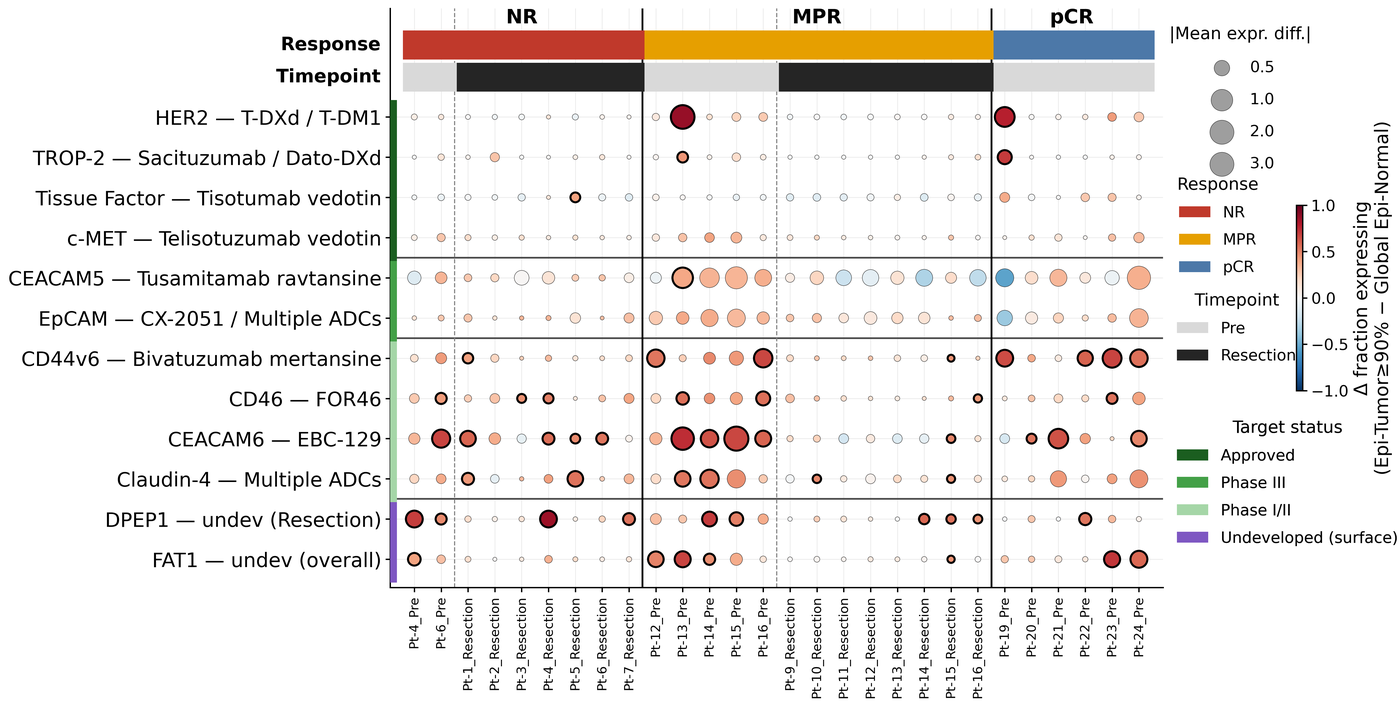

In [ ]:
# Curated ADC-target dot-plot (Fig 5b)
Image(str(VHD / "adc_target_dotplot_epi_global_normal_fig5b.png"))